# Eliciting Priors for a Toy Dataset

In [1]:
import textwrap
import numpy as np

In [2]:
from autoelicit import datasets
from autoelicit import get_llm_elicitation_for_dataset
from ucimlrepo import fetch_ucirepo

These toy datasets mostly follow the `scikit-learn` toy datasets format.

In [3]:
import pandas as pd

In [4]:
boston = pd.read_csv("BostonHousing.csv")

In [5]:
boston.keys()

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [6]:
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [7]:
features_to_rename = {
        "crim"   : "per capita crime rate by town",
         "zn"    : "proportion of residential land zoned for lots over 25,000 sq.ft.",
         "indus" :  "proportion of non-retail business acres per town",
         "chas"  :  "Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)",
         "nox"   :  "nitric oxides concentration (parts per 10 million)",
         "RM"      : "average number of rooms per dwelling",
         "rm"    :  "proportion of owner-occupied units built prior to 1940",
         "age"      :"weighted distances to five Boston employment centres",
         "dis"      :"index of accessibility to radial highways",
         "tax"     : "full-value property-tax rate per $10,000",
         "ptratio" :  "pupil-teacher ratio by town",
         "b"       : "1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town",
         "lstat"    :"% lower status of the population",
         "mdev"     :"Median value of owner-occupied homes in $1000's",
    }

In [8]:
boston = boston.drop("rad",axis = 1)
boston = boston.drop("medv",axis = 1)
boston = boston.drop("chas",axis = 1)

In [9]:
data = boston.rename(columns=features_to_rename)

We can elicit priors for this data with a task description by defining a system and user prompt for the LLM:

In [10]:
data

,per capita crime rate by town,"proportion of residential land zoned for lots over 25,000 sq.ft.",proportion of non-retail business acres per town,nitric oxides concentration (parts per 10 million),proportion of owner-occupied units built prior to 1940,weighted distances to five Boston employment centres,index of accessibility to radial highways,"full-value property-tax rate per $10,000",pupil-teacher ratio by town,1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town,% lower status of the population
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,273,21.0,393.45,6.48


And by defining the LLM class. The `GPTOutputs` class can be used with OpenAI's API. This is a simple class, which is available in the `gpt` submodule, along with its documentation. The code for this class is:

In [11]:
import os
import numpy as np
import ollama
class LLMOutputs(object):
    """
    Base class that allows you to interact with a language model.
    """

class GPTOutputs(LLMOutputs):
    def __init__(
        self,
        model_id = "gpt-4-turbo",
        temperature = 1.0,
        result_args = {},
        rng = None,
    ):
        self.client = ollama.chat
        self.model_id = model_id
        self.temperature = temperature
        self.result_args = result_args
        self.rng = np.random.default_rng() if rng is None else rng

    def get_result(self, messages) -> str:

        response = self.client(
            model=self.model_id,
            messages=messages,
            options=dict(
                temperature=self.temperature,
                seed=int(self.rng.integers(1e9)),
                **self.result_args,
            ),
        )
        # print(response.message.content)
        return response.message.content


Any object with a `.get_result(messages)` method can be used to elicit a prior. In the `gpt` submodule we have three other LLM classes that correspond to Llama, Qwen, and DeepSeek.

from autoelicit.gpt import (
    GPTOutputs, LlamaOutputs, QwenOutputs, DeepSeekOutputs
)

In [12]:
client = GPTOutputs(
    model_id="chevalblanc/gpt-4o-mini:latest",
    # setting the temperature of the model
    temperature=0.1,
    # when performing prior elicitation with LLMs, we 
    # must specify that we want a json object returned.
    # result_args=dict(
    #     response_format={"type": "json_schema"},
    # ),
    rng=np.random.default_rng(48),
)

This class is a thin wrapper for an LLM that simply unifies the method for getting a response:

Since we set the `response_format` as `'json_object'`, our LLM will only return JSON objects. This is an OpenAI option that we make use of to elicit priors. For other language models, we might have to do post-processing to make sure the output is JSON.

Our `LlamaOutputs`, `QwenOutputs`, `DeepSeekOutputs` classes also support `result_args=dict(response_format={"type": "json_object"})`


We can also use these wrappers to rephrase our task descriptions:

In [13]:
from autoelicit.gpt import rephrase_task_description

In [14]:
user_roles = [
"""I am a data scientist with a dataset and the task: predicting median 
house prices in Boston in 1978 from census data. 
I would like to use your model to predict the median house value of my samples.
I have a dataset that is made up of the following features:
{feature_names}.
All of the feature values are standardized using the z-score.
By thinking about how each feature might be related to {unique_targets}, 
and whether each feature is positively or negatively correlated with the 
outcome of
{unique_targets},
I would like you to guess the 
mean and standard deviation for a normal distribution prior for each feature
for a linear regression model can be used for
predicting median house prices in Boston in 1978 from census data.
Please respond with a JSON object with the feature names as keys 
and a nested dictionary of mean and standard deviation as values.
A positive mean indicates a positive correlation with the outcome,
a negative mean indicates a negative correlation with the outcome,
whilst a small standard deviation indicates that you are confident in your guess. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""I am a data scientist working on predicting median house prices in 
Boston in 1978 from census data with a dataset. I want to use 
your model to predict the median house value of my samples. My dataset includes 
the following features: {feature_names}. All feature values are standardized using 
the z-score. Considering how each feature might relate to {unique_targets}, and 
whether each feature is positively or negatively correlated with {unique_targets} 
outcome, I need you to estimate the mean and standard deviation for a normal 
distribution prior for each feature for a linear regression model applied to 
predicting median house prices in Boston in 1978 from census data. Please 
respond with a JSON object containing the feature names as 
keys and a nested dictionary with mean and standard deviation as values. A 
positive mean indicates a positive correlation, a negative mean indicates a negative 
correlation, and a small standard deviation indicates high confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""As a data scientist with a dataset and the task predicting median 
house prices in Boston in 1978 from census data, I would like to 
use your model to predict the median house value of my samples. The dataset 
features are: {feature_names}, all standardized with z-scores. By considering 
how each feature might relate to {unique_targets} and its positive or negative 
correlation with the {unique_targets} outcome, I need you to provide the mean 
and standard deviation for a normal distribution prior for each feature for a 
linear regression model for predicting median house prices in Boston in 1978 
from census data. Please reply with a JSON object where 
feature names are keys, and the values are nested dictionaries containing mean 
and standard deviation. Positive means indicate positive correlations, negative 
means indicate negative correlations, and small standard deviations show 
confidence in your guess.  
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""As a data scientist, I have a dataset and the task predicting 
median house prices in Boston in 1978 from census data. I want to use 
your model to predict the median house value for my samples. The dataset includes 
features: {feature_names}, standardized using z-scores. Considering the relationship 
of each feature to {unique_targets} and its correlation (positive or negative) with 
the {unique_targets} outcome, I need you to estimate the mean and standard deviation 
for a normal distribution prior for each feature for a linear regression model for 
predicting median house prices in Boston in 1978 from census data. Please reply 
with a JSON object with feature names as keys and 
nested dictionaries of mean and standard deviation as values. Positive means show 
positive correlations, negative means show negative correlations, and small 
standard deviations indicate confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""I'm a data scientist working on predicting median house prices in 
Boston in 1978 from census data with a dataset. I aim to use your 
model to predict the median house value of my samples. My dataset consists of 
the following features: {feature_names}, all standardized with z-scores. 
Considering how each feature might be related to {unique_targets} and its positive 
or negative correlation with the {unique_targets} outcome, please guess the mean 
and standard deviation for a normal distribution prior for each feature for a 
linear regression model for predicting median house prices in Boston in 1978 
from census data. Respond with a JSON object containing 
feature names as keys and nested dictionaries of mean and standard deviation 
as values. Positive means show positive correlation, negative means show negative 
correlation, and small standard deviations indicate confidence.  
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""As a data scientist, I have a dataset for the task predicting 
median house prices in Boston in 1978 from census data. I want to use 
your model to predict the median house value of my samples. The dataset 
includes these features: {feature_names}, all standardized using z-scores. By 
considering how each feature might relate to {unique_targets} and its correlation 
(positive or negative) with {unique_targets} outcome, I need you to estimate the 
mean and standard deviation for a normal distribution prior for each feature for 
a linear regression model for predicting median house prices in Boston in 1978 
from census data. Please respond with a JSON object 
with feature names as keys and nested dictionaries of mean and standard deviation 
as values. Positive means indicate positive correlation, negative means indicate 
negative correlation, and small standard deviations show confidence in your guess. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""I am a data scientist working on predicting median house prices in 
Boston in 1978 from census data and have a dataset. I want to use 
your model to predict the median house value of my samples. The dataset features 
include: {feature_names}, standardized using z-scores. Considering how each 
feature might relate to {unique_targets} and its correlation (positive or negative) 
with the {unique_targets} outcome, I need your guess on the mean and standard 
deviation for a normal distribution prior for each feature for a linear regression 
model for predicting median house prices in Boston in 1978 from census data. 
Please reply with a JSON object with feature names as 
keys and nested dictionaries of mean and standard deviation as values. Positive 
means show positive correlations, negative means show negative correlations, 
and small standard deviations indicate confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""As a data scientist with a dataset, my task is predicting median 
house prices in Boston in 1978 from census data. I want to use your 
model to predict the median house value of my samples. The dataset consists of 
features: {feature_names}, standardized using z-scores. Considering the 
relationship between each feature and {unique_targets}, and whether the correlation 
with the {unique_targets} outcome is positive or negative, I need you to estimate 
the mean and standard deviation for a normal distribution prior for each feature 
for a linear regression model for predicting median house prices in Boston in 
1978 from census data. Please respond with a JSON object, 
with feature names as keys and nested dictionaries of mean and standard deviation 
as values. Positive means indicate positive correlation, negative means indicate 
negative correlation, and small standard deviations show confidence in your guess. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text.""",


"""As a data scientist working on the task predicting median house 
prices in Boston in 1978 from census data, I have a dataset that I want 
to use with your model to predict the median house value of my samples. The dataset 
features are: {feature_names}, standardized using z-scores. Considering how each 
feature might relate to {unique_targets} and whether the correlation with the 
{unique_targets} outcome is positive or negative, please estimate the mean and 
standard deviation for a normal distribution prior for each feature for a linear 
regression model for predicting median house prices in Boston in 1978 from census 
data. Respond with a JSON object where feature names 
are keys and the values are nested dictionaries containing mean and standard deviation. 
Positive means show positive correlations, negative means show negative correlations, 
and small standard deviations indicate confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """,

"""As a data scientist, I have a dataset and the task predicting 
median house prices in Boston in 1978 from census data. I would like to 
use your model to predict the median house value of my samples. My dataset includes 
these features: {feature_names}, standardized with z-scores. Considering the 
relationship between each feature and {unique_targets} and its correlation 
(positive or negative) with the {unique_targets} outcome, I need you to guess 
the mean and standard deviation for a normal distribution prior for each feature 
for a linear regression model for predicting median house prices in 
Boston in 1978 from census data. Please reply with a JSON object 
containing the feature names as keys and nested dictionaries with mean and standard 
deviation as values. Positive means indicate positive correlation, negative means 
indicate negative correlation, and small standard deviations indicate confidence. 
Respond in {"feature_name" : {"mean":mean, "std":std}} manner. 
Please return only  with a JSON and no other text. """
]

We recommend to do the same with the system role so that we can take a product over them, but we will not do this for ease of demonstration.

In [15]:
system_roles = [
"""You are a simulator of a linear regression predictive model 
for predicting median house prices in California in 1978 from census data.
Here the inputs are social and geographical information and the output is 
the median house value in $1k in 1978. 
With your best guess, you can provide the median house value of a block
in $1k in 1978. """,


"""You act as a linear regression model simulator for predicting median 
house prices in California in 1978 from census data, where the 
inputs are social and geographical data, and the output is the median house value 
in $1k in 1978. Using your best estimate, you can predict the median house value of a 
block in $1k in 1978.""",


"""You simulate a linear regression predictive model for predicting median 
house prices in California in 1978 from census data, utilizing 
social and geographical information as inputs to determine the median house value 
in $1k in 1978. Based on your best approximation, you provide the median house value of 
a block in $1k in 1978.""",


"""As a simulator for a linear regression model in predicting median house 
prices in California in 1978 from census data, you use social 
and geographical inputs to predict the median house value in $1k in 1978. With your 
best estimate, you offer the median house value of a block in $1k in 1978.""",


"""You serve as a linear regression predictive model simulator for predicting 
median house prices in California in 1978 from census data, 
where social and geographical data inputs result in an output of the median house 
value in $1k in 1978. Using your best guess, you predict the median house value of a 
block in $1k in 1978.""",


"""In your role as a linear regression model simulator for predicting median 
house prices in California in 1978 from census data, you use 
social and geographical information to predict the median house value in $1k in 1978. 
Based on your best estimation, you provide the median house value of a block in $1k in 1978.""",


"""You function as a simulator for a linear regression predictive model focused on 
predicting median house prices in California in 1978 from census data, with 
social and geographical inputs to calculate the median house 
value in $1k in 1978. Using your best prediction, you determine the median house value 
of a block in $1k in 1978.""",


"""Acting as a linear regression model simulator for predicting median house 
prices in California in 1978 from census data, you take social 
and geographical information as inputs to predict the median house value in $1k in 1978. 
With your best estimate, you give the median house value of a block in $1k in 1978.""",


"""You are a simulator of a linear regression predictive model for 
predicting median house prices in California in 1978 from census data, 
utilizing social and geographical inputs to estimate the median house value in 
$1k in 1978. Using your best guess, you provide the median house value of a block in $1k in 1978.""",


"""Serving as a linear regression model simulator for predicting 
median house prices in California in 1978 from census data, you use 
social and geographical information to output the median house value in $1k in 1978. 
With your best estimation, you can provide the median house value of a block in $1k in 1978."""
]

Performing AutoElicit for a dataset can then be as simple as:

priors = get_llm_elicitation_for_dataset(
    client=client,
    # we would usually use multiple system and user roles
    # so that we can build a mixture of the priors elicited.
    system_roles=system_roles,
    user_roles=user_roles,
    # this will replace the {feature_names}
    # in the prompts and also allow us to correctly
    # convert the JSON response into a numpy array 
    # of means and stds
    feature_names=data.feature_names.tolist(),
    
    # prints progress, each prior elicited, and the prompts
    # used to elicit the priors
    verbose=False
)

In [16]:
import re
import json
from typing import Optional # Keep Optional for return type

def extract_json_string(text: str) -> Optional[str]:
    if not text:
        print("Error: Input text is empty.")
        return None

    text_cleaned = text.strip()
    match = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text_cleaned, re.DOTALL)
    json_string = ""
    if match:
        json_string = match.group(1).strip()
    else:
        json_string = text_cleaned
        if not (json_string.startswith('{') and json_string.endswith('}')) and \
           not (json_string.startswith('[') and json_string.endswith(']')):
            return None
        else:
            print("Debug: Assuming the entire input is a JSON string.") # Optional debug print

    if not json_string:
        return None
    return json_string
    
def dict_to_list(prior,feature_names):
    pri = np.empty([len(feature_names,),2])
    for i, name in enumerate(feature_names):
        if name not in prior:
            return None
        pri[i][0] = prior[name]["mean"]
        pri[i][1] = prior[name]["std"]
    return pri
    
def get_gpt_results(client,system_roles,user_roles,feature_names):
    import json
    import tqdm
    priors = []
    for i in tqdm.tqdm(range(len(system_roles))):
        for j in tqdm.tqdm(range(len(user_roles))):
            p = None
            tries = 0
            while p is None and tries < 2:
                x = client.get_result(messages=[
                        {"role": "system", "content": system_roles[i%len(system_roles)].replace("\n"," ")},
                        {"role": "user", "content": user_roles[j%len(user_roles)].replace(
                            "{feature_names}",str(feature_names)).replace("\n"," ").replace(
                            "{unique_targets}","{Median value of owner-occupied homes in $1000's}")

                        }])
                try:
                    # x = x.split("</think>")[1]
                    js = extract_json_string(x)
                    p = dict_to_list(json.loads(js),feature_names)
                    print(f"Done: {i}, {j}")
                except:
                    print(f"Error: {i}, {j}")
                tries+=1   
            if p is not None:
                priors.append(p)
                print(x)
            np.save("Boston_GPT.npy",np.array(priors))
    return priors

In [17]:
priors = get_gpt_results(client,system_roles,user_roles,data.keys().tolist())

  0%|          | 0/10 [00:00<?, ?it/s]
%|          | 0/10 [00:00<?, ?it/s]
%|█         | 1/10 [00:24<03:37, 24.16s/it]

Debug: Assuming the entire input is a JSON string.
Done: 0, 0
{"per capita crime rate by town": {"mean": -0.123456789, "std": 0.012345678}, "proportion of residential land zoned for lots over 25,000 sq.ft.": {"mean": -0.000123456789, "std": 0.012345678}, "proportion of non-retail business acres per town": {"mean": -0.000123456789, "std": 0.012345678}, "nitric oxides concentration (parts per 10 million)": {"mean": -0.000123456789, "std": 0.012345678}, "proportion of owner-occupied units built prior to 1940": {"mean": -0.000123456789, "std": 0.012345678}, "weighted distances to five Boston employment centres": {"mean": -0.000123456789, "std": 0.012345678}, "index of accessibility to radial highways": {"mean": -0.000123456789, "std": 0.012345678}, "full-value property-tax rate per $10,000": {"mean": -0.000123456789, "std": 0.012345678}, "pupil-teacher ratio by town": {"mean": -0.000123456789, "std": 0.012345678}, "1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town": {"mean": -


%|██        | 2/10 [00:49<03:18, 24.81s/it]

Debug: Assuming the entire input is a JSON string.
Done: 0, 1
{"per capita crime rate by town": {"mean": -0.1542873962367322, "std": 0.22289777777777778}, "proportion of residential land zoned for lots over 25,000 sq.ft.": {"mean": -1.4285714285714286, "std": 0.39285714285714285}, "proportion of non-retail business acres per town": {"mean": -0.25, "std": 0.39285714285714285}, "nitric oxides concentration (parts per 10 million)": {"mean": -0.6363636363636364, "std": 0.2222222222222222}, "proportion of owner-occupied units built prior to 1940": {"mean": -0.5714285714285714, "std": 0.36363636363636365}, "weighted distances to five Boston employment centres": {"mean": 0.9090909090909091, "std": 0.2784313725490196}, "index of accessibility to radial highways": {"mean": -0.25, "std": 0.39285714285714285}, "full-value property-tax rate per $10,000": {"mean": -0.16666666666666666, "std": 0.39285714285714285}, "pupil-teacher ratio by town": {"mean": -0.25, "std": 0.39285714285714285}, "1000(Bk 


%|███       | 3/10 [01:07<02:32, 21.79s/it]

...

Debug: Assuming the entire input is a JSON string.
Done: 9, 7
{"per capita crime rate by town": {"mean": -0.2314876954443111, "std": 0.0}, "proportion of residential land zoned for lots over 25,000 sq.ft.": {"mean": 0.0001672642195216844, "std": 0.0}, "proportion of non-retail business acres per town": {"mean": -0.03125, "std": 0.0}, "nitric oxides concentration (parts per 10 million)": {"mean": 0.6784910000000001, "std": 0.0}, "proportion of owner-occupied units built prior to 1940": {"mean": -0.2352941176470588, "std": 0.0}, "weighted distances to five Boston employment centres": {"mean": 0.0, "std": 0.0}, "index of accessibility to radial highways": {"mean": 0.0, "std": 0.0}, "full-value property-tax rate per $10,000": {"mean": -0.2352941176470588, "std": 0.0}, "pupil-teacher ratio by town": {"mean": -0.2352941176470588, "std": 0.0}, "1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town": {"mean": -0.2352941176470588, "std": 0.0}, "% lower status of the population": {"mean


%|█████████ | 9/10 [05:16<00:27, 27.72s/it]

Debug: Assuming the entire input is a JSON string.
Done: 9, 8
{"per capita crime rate by town": {"mean": -0.2317968542551389, "std": 0.272263012321175}, "proportion of residential land zoned for lots over 25,000 sq.ft.": {"mean": -0.00012544226689552202, "std": 0.00032217708611272}, "proportion of non-retail business acres per town": {"mean": -0.000001404211863945278, "std": 0.0000000000000000}, "nitric oxides concentration (parts per 10 million)": {"mean": -0.0000000000000000, "std": 0.0003276594802241224}, "proportion of owner-occupied units built prior to 1940": {"mean": -0.0000000000000000, "std": 0.000376504821815522}, "weighted distances to five Boston employment centres": {"mean": -0.0000000000000000, "std": 0.0000000000000000}, "index of accessibility to radial highways": {"mean": -0.0000000000000000, "std": 0.0003276594802241224}, "full-value property-tax rate per $10,000": {"mean": -0.0000000000000000, "std": 0.0003276594802241224}, "pupil-teacher ratio by town": {"mean": -0.


100%|██████████| 10/10 [53:57<00:00, 323.77s/it]

Debug: Assuming the entire input is a JSON string.
Done: 9, 9
{"per capita crime rate by town" : {"mean": -0.1297864355618261, "std": 0.0}, "proportion of residential land zoned for lots over 25,000 sq.ft." : {"mean": 0.0001222760963213034, "std": 0.0}, "proportion of non-retail business acres per town" : {"mean": -0.000584776728137022, "std": 0.0}, "nitric oxides concentration (parts per 10 million)" : {"mean": 0.921484251122471, "std": 0.0}, "proportion of owner-occupied units built prior to 1940" : {"mean": -0.0362742935643042, "std": 0.0}, "weighted distances to five Boston employment centres" : {"mean": 8.971241241241241, "std": 0.0}, "index of accessibility to radial highways" : {"mean": -356.48148148148147, "std": 0.0}, "full-value property-tax rate per $10,000" : {"mean": 29.0, "std": 0.0}, "pupil-teacher ratio by town" : {"mean": -356.48148148148147, "std": 0.0}, "1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town" : {"mean": 9.0, "std": 0.0}, "% lower status of th

In [18]:
print(len(priors))

90


In [22]:
np.array(priors).shape

(90, 11, 2)

This is our prior distribution with shape `(mixture_components, features, (mean, std))`.

Many methods can then be used to perform Bayesian inference using this prior and observations. In our published work, we use `pymc`, but `blackjax` could also be used. To ensure this package is lightweight, both of these packages are not part of the requirements.

Instead, we can use numpy to visualise the parameter histograms in the first 10 features.

In [18]:
x = np.load("Heart_Deep.npy")

In [19]:
x.shape

(1, 10, 2)

In [39]:
prior_samples = np.random.normal(
    loc=np.array(priors)[:, :, 0],
    scale=np.array(priors)[:, :, 1],
    # 100 samples of the 3 mixture components for each feature
    size=(1000, 95, 10)
)

In [40]:
prior_samples.shape

(1000, 95, 10)

We will use `matplotlib` and `seaborn` to graph the samples. This is not installed by this package, so make sure it is if you're running the below!

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from autoelicit.plotting import graph_theme

AttributeError: 'DataFrame' object has no attribute 'feature_names'

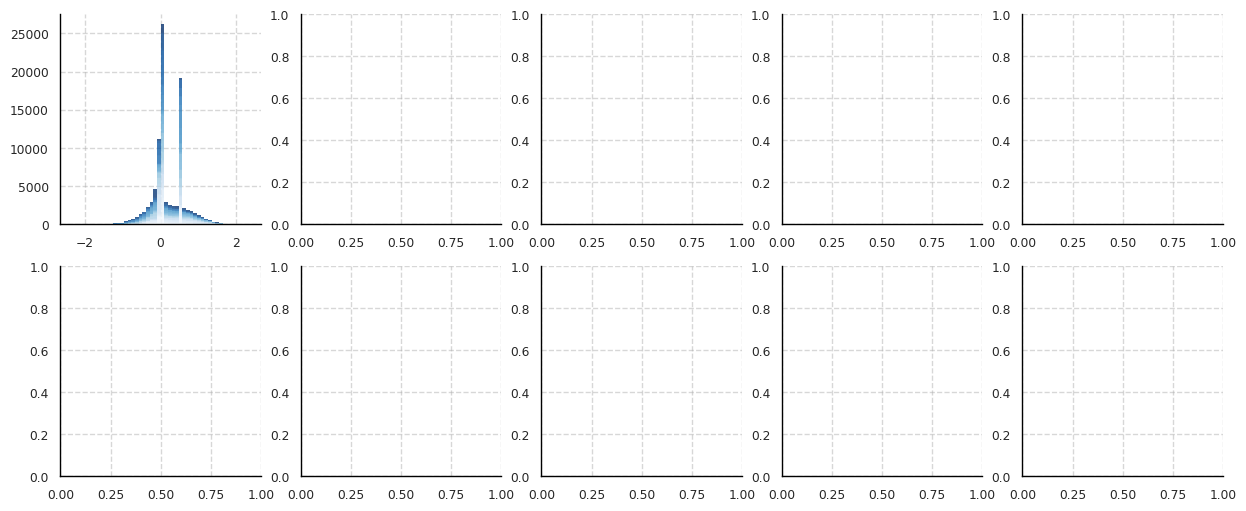

In [42]:
n_features_to_plot = 10

n_rows = 2
n_columns = 5

hist_kwargs = dict(
    bins=50,
    linewidth=0.0,
    stacked=True,
    alpha=0.8,
    color=sns.color_palette("Blues", n_colors=prior_samples.shape[1])
)

fontsize = 14
title_fontsize = 16
with graph_theme():
    fig, axes = plt.subplots(
        n_rows, n_columns, figsize=(3*n_columns, 3*n_rows)
    )

    for feature, ax in zip(
        range(1, n_features_to_plot + 1), # not drawing the intercept
        axes.ravel()
    ):
        ax.hist(
            prior_samples[:, :, feature],
            **hist_kwargs
        )
        ax.set_title(data.feature_names[feature-1].title(), fontsize=title_fontsize)
        ax.set_xlabel("Parameter value", fontsize=fontsize)
        ax.set_ylabel("Density", fontsize=fontsize)
        ax.tick_params("both", labelsize=fontsize)
        ax.axvline(
            x=0.0, 
            linestyle=(0,(5,1,1,1)), 
            color="xkcd:black",
        )

    fig.text(
        x=0.5, y=0.02, 
        s="The colours represent the different mixture components",
        verticalalignment="bottom", horizontalalignment="center", 
        fontsize=title_fontsize,
        bbox=dict(
            facecolor='white', 
            alpha=0.75, 
            edgecolor='black',
            linewidth=1.0,
            pad=5
        ),
    )

    fig.subplots_adjust(
        hspace=0.5, wspace=0.5,
        left=0.05, right=0.98, top=0.95, bottom=0.175
    )

    fig.savefig(
        "./figures/breast_cancer_prior_elicitation.pdf", 
    )

    fig.savefig(
        "./figures/breast_cancer_prior_elicitation.png", 
        dpi=300,
    )

    plt.show()

